In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
import warnings

In [2]:
# ==========================================
# Import experimental data
# ==========================================
 
data = pd.read_csv("Dataset1.csv")
 
t_data = data["t"].values
X_data = data["X"].values
S_data = data["S"].values
P_data = data["P"].values
 
# Initial conditions taken from first row
X0 = X_data[0]
S0 = S_data[0]
P0 = P_data[0]

#constants based on data
Xmdata = X_data.max()
Yxsdata = Xmdata / (S_data.max() - S_data.min())
Pmdata = P_data.max()
Ypsdata = Pmdata / (S_data.max() - S_data.min())

In [3]:
S_data.max() - S_data.min()

np.float64(27.810650885999998)

In [4]:
X0

np.float64(0.24852071)

In [5]:
data.head

<bound method NDFrame.head of              t          S         X         P
0     0.000000  33.017751  0.248521  0.000000
1    16.972169  27.218935  2.946746  0.497041
2    40.653641  22.366864  3.337278  1.171598
3    63.556969  16.923077  3.301775  2.165680
4    81.320115  13.491124  3.337278  2.733728
5   150.009100   6.153846  2.307692  5.076923
6   156.318248  33.964497  3.337278  5.076923
7   174.503715  32.071006  3.514793  6.497041
8   197.041887  28.875740  2.449704  8.378698
9   220.334870  26.863905  2.272189  9.230769
10  242.831044  24.378698  1.952663  9.834320>

In [6]:
# ==========================================
# Model equations
# ==========================================
 
def model(t, y, params):
    X, S, P = y
    mu_m, Xm, Ki, Yxs, Yps, m, alpha, beta, Ksp, Kip = params
    
    # 1. PHYSICAL CAP: Concentrations can never drop below absolute zero
    X = max(X, 0.0)
    S = max(S, 0.0)
    P = max(P, 0.0)
    
    # 2. ZERO PROTECTOR: Prevent parameters from hitting zero and causing dividing-by-zero errors
    Xm_safe  = max(Xm, 1e-4)
    Ki_safe  = max(Ki, 1e-4)
    Ksp_safe = max(Ksp, 1e-4)
    Kip_safe = max(Kip, 1e-4)
    
    # 3. YIELD PROTECTOR: Prevent 1/Yxs from blowing up into infinity
    Yxs_safe = max(Yxs, 1e-4)
    Yps_safe = max(Yps, 1e-4)

    # Calculate derivatives using safe parameters
    dXdt = mu_m * (1 - X / Xm_safe) * (1 / (1 + S / Ki_safe)) * X
    
    # Protect division terms from turning into NaN if S is zero
    p_term1 = S / (S + Ksp_safe) if (S + Ksp_safe) > 0 else 0
    p_term2 = 1 / (1 + S / Kip_safe)
    dPdt = (alpha * dXdt) + (beta * p_term1 * p_term2 * X)
    
    dSdt = -((1 / Yxs_safe) * dXdt) - ((1 / Yps_safe) * dPdt) - (m * X)

    # 4. EXPLOSION CAP: If a derivative spikes into crazy territory, clip it
    # This prevents the solver from taking micro-steps to solve infinite values
    return [
        np.clip(dXdt, -1e4, 1e4),
        np.clip(dSdt, -1e4, 1e4),
        np.clip(dPdt, -1e4, 1e4)
    ]

In [7]:
# ==========================================
# Objective function
# ==========================================
def objective(params):

    with warnings.catch_warnings():
        warnings.filterwarnings("error")

        try:

            feed_time = 150.0090997
            feed_substrate = 33.0

            t_before = t_data[t_data <= feed_time]
            t_after  = t_data[t_data >= feed_time]

            sol1 = solve_ivp(
                lambda t, y: model(t, y, params),
                [t_data[0], feed_time],
                [X0, S0, P0],
                t_eval=t_before,
                method = "LSODA",
                rtol=1e-3,
                atol=1e-5
            )

 

            X_feed = sol1.y[0, -1]
            P_feed = sol1.y[2, -1]
            S_feed = feed_substrate

            sol2 = solve_ivp(
                lambda t, y: model(t, y, params),
                [feed_time, t_data[-1]],
                [X_feed, S_feed, P_feed],
                t_eval=t_after,
                method = "LSODA",
                rtol=1e-3,
                atol=1e-5
            )

            Xhat = np.concatenate([sol1.y[0], sol2.y[0][1:]])
            Shat = np.concatenate([sol1.y[1], sol2.y[1][1:]])
            Phat = np.concatenate([sol1.y[2], sol2.y[2][1:]])

            if not sol1.success or not sol2.success:
                return 1e20
            
            if np.any(Xhat < -1e-3) or np.any(Shat < -1e-3) or np.any(Phat < -1e-3):
                return 1e20

            rss = np.sum(((X_data - Xhat)/X_data.max())**2)
            rss += np.sum(((S_data - Shat)/S_data.max())**2)
            rss += np.sum(((P_data - Phat)/P_data.max())**2)

            return rss

        except Exception as e:
            print("ODE ERROR:", e)
            return 1e20

In [8]:
# ==========================================
# Callback function
# ==========================================
import time

generation_history = []
rss_history = []

start_time = time.time()
generation = 0

def callback(intermediate_result):
    global generation
    generation += 1

    elapsed = time.time() - start_time
    
    # Extract data directly without re-running the ODE solver
    current_rss = intermediate_result.fun
    convergence = intermediate_result.convergence

    generation_history.append(generation)
    rss_history.append(current_rss)
    
    print(
        f"\rGeneration {generation:3d} | "
        f"RSS = {current_rss:.6f} | "
        f"Conv = {convergence:.3e} | "
        f"Time = {(elapsed/60):.1f} min\033[K",
        end="",
        flush=True
    )

In [9]:
# ==========================================
# Parameter optimization
# ==========================================
# mu_m, Xm, Ki, Yxs, Yps, m, alpha, beta, Ksp, Kip  = params
#bounds = [
    #(0.001,10), # mu_m
    #(Xmdata * 0.9,Xmdata * 1.1), # Xm
    #(1,200), # Ki
    #(Yxsdata * 0.9,Yxsdata * 1.1), #Yxs
    #(Ypsdata * 0.9,Ypsdata * 1.1), #Yps
    #(0.001,1), #m 
    #(0.001,10), #alpha
    #(0.001,10), #beta
    #(0.001,10), #Ksp
    #(1,150) #Kip
#]

bounds = [
    (0.0001,5), # mu_m
    (1,200), # Xm
    (0.01,100), # Ki
    (0.01,10), #Yxs
    (0.01,10), #Yps
    (0.0001,1), #m
    (0.0001,10), #alpha
    (0.0001,10), #beta
    (0.01,200), #Ksp
    (0.01,150) #Kip
]


result = differential_evolution(
    objective,
    bounds=bounds,
    callback = callback,
    maxiter = 2000,
    seed = 40,
    tol = 0,
    atol = -1,
    strategy='rand1bin',        # 👈 Swaps from greedy 'best' to random coordinate mutation
    mutation=(0.5, 1.9),        # 👈 Expands mutation scaling to allow massive search steps
    recombination=0.3,          # 👈 Lower value retains original variable traits longer
    init='latinhypercube',      # 👈 Guarantees uniform spatial positioning at launch
    polish=True                 # 👈 Cleans up the wide search with a tight gradient lock
)
 
best_params = result.x

Generation   1 | RSS = 315.270075 | Conv = 0.000e+00 | Time = 0.0 min

Generation   2 | RSS = 315.270075 | Conv = 0.000e+00 | Time = 0.1 min

Generation   3 | RSS = 315.270075 | Conv = 0.000e+00 | Time = 0.1 min

Generation   4 | RSS = 315.270075 | Conv = 0.000e+00 | Time = 0.1 min

Generation   5 | RSS = 62.196121 | Conv = 0.000e+00 | Time = 0.1 min

...

Generation 1996 | RSS = 0.324541 | Conv = 0.000e+00 | Time = 25.5 min

Generation 1997 | RSS = 0.324541 | Conv = 0.000e+00 | Time = 25.5 min

Generation 1998 | RSS = 0.324541 | Conv = 0.000e+00 | Time = 25.5 min

Generation 1999 | RSS = 0.324541 | Conv = 0.000e+00 | Time = 25.5 min

Generation 2000 | RSS = 0.324541 | Conv = 0.000e+00 | Time = 25.5 min

In [10]:
total_time = time.time() - start_time

print("Function evaluations:", result.nfev)
print("Iterations:", result.nit)
print("Best objective:", result.fun)
print("total time:", total_time/60, " mins")

Function evaluations: 300502
Iterations: 2000
Best objective: 0.3104479082234326
total time: 25.553992239634194  mins


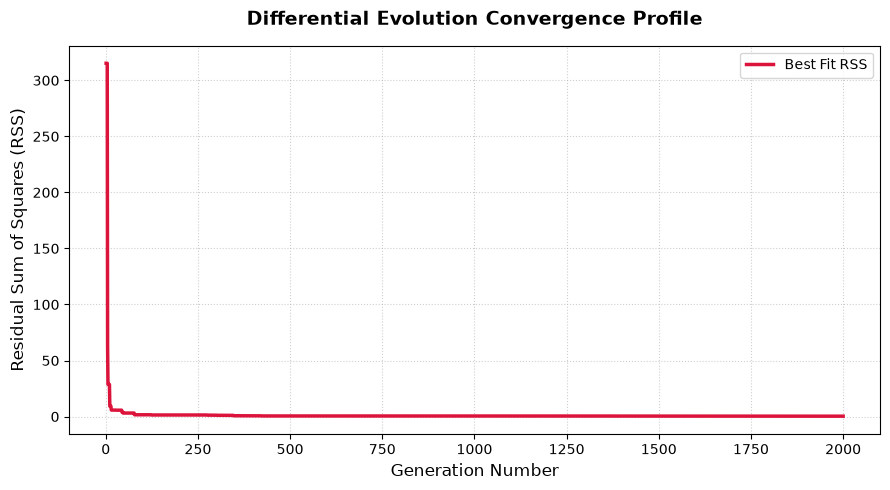

In [11]:
# ==========================================
# Plotting the Optimization Convergence
# ==========================================
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))

# Plot the progression line
plt.plot(generation_history, rss_history, color="crimson", linewidth=2.5, label="Best Fit RSS")

# Aesthetic adjustments
plt.title("Differential Evolution Convergence Profile", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Generation Number", fontsize=12)
plt.ylabel("Residual Sum of Squares (RSS)", fontsize=12)

# If your initial RSS is massive (like 1e20), log scale will protect the graph visual
if max(rss_history) > 1e4:
    plt.yscale("log")
    plt.ylabel("Residual Sum of Squares (RSS) [Log Scale]", fontsize=12)

plt.grid(True, linestyle=":", alpha=0.6, which="both")
plt.legend(frameon=True, facecolor="white")
plt.tight_layout()

# Show the chart
plt.show()

In [12]:
# ==========================================
# Simulate best-fit model for fit metrics
# ==========================================

feed_time = 150.0090997
feed_substrate = 33.0

t_before = t_data[t_data <= feed_time]
t_after  = t_data[t_data >= feed_time]

sol1 = solve_ivp(
    lambda t, y: model(t, y, best_params),
    [t_data[0], feed_time],
    [X0, S0, P0],
    t_eval=t_before
)



X_feed = sol1.y[0, -1]
P_feed = sol1.y[2, -1]
S_feed = feed_substrate

sol2 = solve_ivp(
    lambda t, y: model(t, y, best_params),
    [feed_time, t_data[-1]],
    [X_feed, S_feed, P_feed],
    t_eval=t_after
)


Xhat = np.concatenate([sol1.y[0], sol2.y[0][1:]])
Shat = np.concatenate([sol1.y[1], sol2.y[1][1:]])
Phat = np.concatenate([sol1.y[2], sol2.y[2][1:]])

In [13]:
# ==========================================
# Goodness-of-fit metrics
# ==========================================
 
def r_squared(y_obs, y_pred):
 
    rss = np.sum((y_obs - y_pred)**2)
    tss = np.sum((y_obs - np.mean(y_obs))**2)
 
    return 1 - rss/tss
 
def rmse(y_obs, y_pred):
 
    return np.sqrt(np.mean((y_obs - y_pred)**2))
 
R2_X = r_squared(X_data, Xhat)
R2_S = r_squared(S_data, Shat)
R2_P = r_squared(P_data, Phat)
 
RMSE_X = rmse(X_data, Xhat)
RMSE_S = rmse(S_data, Shat)
RMSE_P = rmse(P_data, Phat)

In [14]:
# mu_m, Xm, Ki, Yxs, Yps, m, alpha, beta, Ksp, Kip  = params
parameter_names = [
    "mu_m",
    "Xm",
    "Ki",
    "Yxs",
    "Yps",
    "m",
    "alpha",
    "beta",
    "Ksp",
    "Kip"
]
 
print("\nEstimated Parameters")
print("--------------------")
for name, value in zip(parameter_names, best_params):
    print(f"{name:10s} = {value:.6f}")
print("\n")
print(f"Xmdata = {Xmdata:.4f}")
print(f"Yxsdata = {Yxsdata:.4f}")
print(f"Pmdata = {Pmdata:.4f}")
print(f"Ypsdata = {Ypsdata:.4f}")
print("\nGoodness of Fit")
print("--------------------")
print(f"X : R² = {R2_X:.4f} RMSE = {RMSE_X:.4f}")
print(f"S : R² = {R2_S:.4f} RMSE = {RMSE_S:.4f}")
print(f"P : R² = {R2_P:.4f} RMSE = {RMSE_P:.4f}")
print(f"\nObjective Function (RSS) = {result.fun:.6f}")


Estimated Parameters
--------------------
mu_m       = 1.197556
Xm         = 2.878619
Ki         = 48.241250
Yxs        = 0.389969
Yps        = 1.970370
m          = 0.035553
alpha      = 0.043767
beta       = 0.178600
Ksp        = 169.474422
Kip        = 55.463886


Xmdata = 3.5148
Yxsdata = 0.1264
Pmdata = 9.8343
Ypsdata = 0.3536

Goodness of Fit
--------------------
X : R² = 0.6796 RMSE = 0.5185
S : R² = 0.9272 RMSE = 2.2564
P : R² = 0.9824 RMSE = 0.4492

Objective Function (RSS) = 0.310448


In [15]:
# ==========================================
# Simulate best-fit model for plotting
# ==========================================
t_start = 0
t_end = t_data.max()
dt = 0.2 #every 12 minutes

t_sim = np.arange(
    t_start,
    t_end + dt,
    dt
    )

feed_time = 150.0090997
feed_substrate = 33.0

t_before = t_sim[t_sim <= feed_time]
t_after  = t_sim[t_sim >= feed_time]

sol1 = solve_ivp(
    lambda t, y: model(t, y, best_params),
    [t_data[0], feed_time],
    [X0, S0, P0],
    t_eval=t_before
)


X_feed = sol1.y[0, -1]
P_feed = sol1.y[2, -1]
S_feed = feed_substrate

sol2 = solve_ivp(
    lambda t, y: model(t, y, best_params),
    [feed_time, t_after[-1]],
    [X_feed, S_feed, P_feed],
    t_eval=t_after
)


Xhat = np.concatenate([sol1.y[0], sol2.y[0][1:]])
Shat = np.concatenate([sol1.y[1], sol2.y[1][1:]])
Phat = np.concatenate([sol1.y[2], sol2.y[2][1:]])

t_hat = np.concatenate([
    sol1.t,
    sol2.t[1:]
])

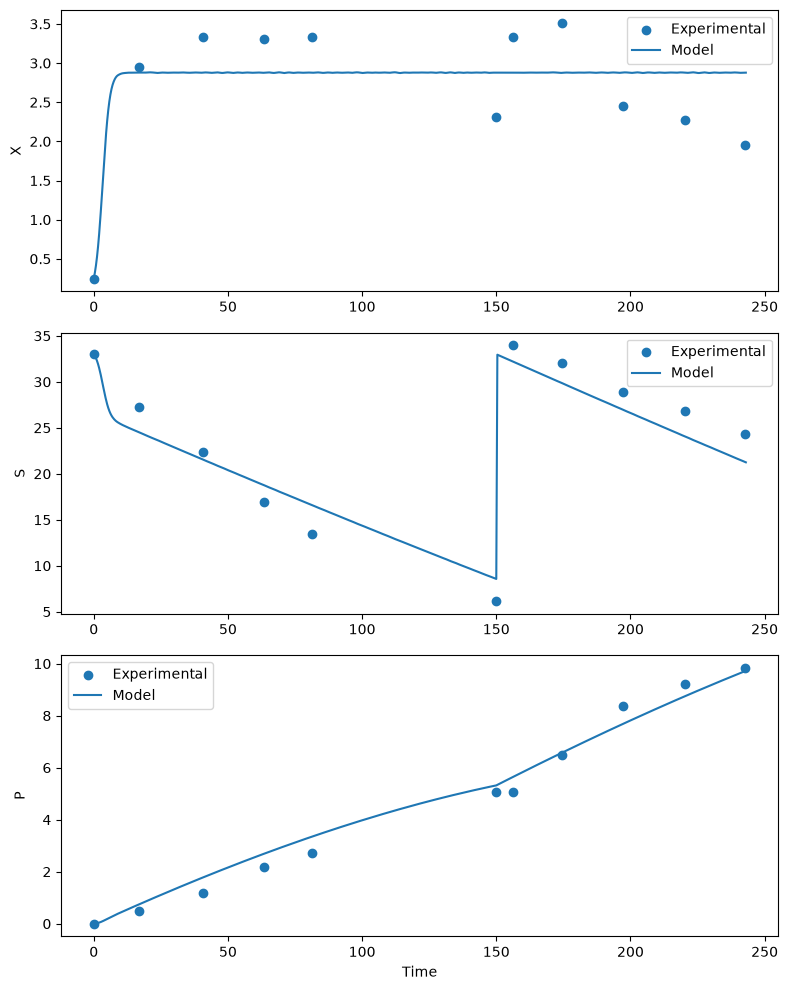

In [16]:
#plotting


fig, ax = plt.subplots(3, 1, figsize=(8, 10))
 
ax[0].scatter(t_data, X_data, label="Experimental")
ax[0].plot(t_hat, Xhat, label="Model")
ax[0].set_ylabel("X")
ax[0].legend()

ax[1].scatter(t_data, S_data, label="Experimental")
ax[1].plot(t_hat, Shat, label="Model")
ax[1].set_ylabel("S")
ax[1].legend()

ax[2].scatter(t_data, P_data, label="Experimental")
ax[2].plot(t_hat, Phat, label="Model")
ax[2].set_ylabel("P")
ax[2].set_xlabel("Time")
ax[2].legend()

plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# Create simulated dataset
# ==========================================

simulated_data = pd.DataFrame({
    "t": t_sim,
    "X": Xhat,
    "S": Shat,
    "P": Phat
})
 
print(simulated_data.head())

ValueError: All arrays must be of the same length

In [18]:
simulated_data.to_csv(
    "optimized_model_dataset1.csv",
    index=False
)

NameError: name 'simulated_data' is not defined